**Βήμα 1: Εγκατάσταση Spark & Mount Drive**

In [ ]:
# Εγκατάσταση
!pip install -q pyspark
!pip install -q gdown

import os
import shutil
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lower, split, explode, concat_ws, regexp_replace, array_intersect, array_union, size, trim
import glob
import time
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Συνάρτηση λήψης
def download_data(folder_id, output_path):
    if os.path.exists(output_path):
        shutil.rmtree(output_path)
    # Κατεβάζουμε αναδρομικά όλο τον φάκελο
    os.system(f"gdown --folder {folder_id} -O {output_path}")
    print(f"Η λήψη στο {output_path} ολοκληρώθηκε.")

# Φόρτωση από προσωπικό ανοιχτό Google Drive
# 1. Fodors-Zagat (Restaurants)
# ID: 1nLlLMgP02hsik-ty7ZeFHhkJLC9Bke3s
download_data("1nLlLMgP02hsik-ty7ZeFHhkJLC9Bke3s", "/content/fodors_root")

# 2. DBLP-ACM (Citations)
# ID: 17LdEUo9-deQeC_sM1Q_60rQyLb_S6zqx
download_data("17LdEUo9-deQeC_sM1Q_60rQyLb_S6zqx", "/content/dblp_root")

Η λήψη στο /content/fodors_root ολοκληρώθηκε.
Η λήψη στο /content/dblp_root ολοκληρώθηκε.


**Βήμα 2: Η Συνάρτηση του Pipeline (Generic Code)**

In [ ]:
# # Αυτό το block κάποιες φορές πρέπει να ξανατρέξει για
# # να τρέξει σωστά το βήμα 3 δεύτερη και και ούτω καθεξής φορά αν βγάλει ERROR μετά την 2η φορά.


# Ρύθμιση Spark
spark = SparkSession.builder \
    .appName("ER_Project") \
    .config("spark.sql.shuffle.partitions", "20") \
    .getOrCreate()

# Γενικά Stopwords
stopwords_list = ["the", "a", "an", "of", "and", "or", "in", "on", "at", "to", "by", "for", "with"]
stopwords_pattern = "\\b(" + "|".join(stopwords_list) + ")\\b"

def run_er_pipeline(spark, dataset_name, base_folder_path, match_columns):

    total_start_time = time.time()
    safe_name = dataset_name.split()[0] # π.χ. FODORS

    # --- 1. Εντοπισμός Αρχείων ---
    found_files = glob.glob(f"{base_folder_path}/**/tableA.csv", recursive=True)
    if not found_files:
        print(f"ERROR: Δεν βρέθηκαν αρχεία CSV στο {base_folder_path}")
        return
    actual_path = os.path.dirname(found_files[0])

    print(f"\n=============================================")
    print(f"DATASET: {dataset_name}")
    print(f"Path: {actual_path}")
    print(f"=============================================")

    # --- 2. Load Data ---
    print(f"[Βήμα 1/6] Φόρτωση Δεδομένων...", end=" ")
    step_start = time.time()
    try:
        # Φορτώνουμε και κρατάμε τα αρχικά DataFrames για να τα έχουμε στο τέλος
        df_a = spark.read.option("header", "true").csv(f"{actual_path}/tableA.csv")
        df_b = spark.read.option("header", "true").csv(f"{actual_path}/tableB.csv")
        print(f"ΟΚ ({time.time() - step_start:.1f} sec)")
    except:
        print("Σφάλμα κατά τη φόρτωση.")
        return

    # --- 3. Preprocessing ---
    print(f"[Βήμα 2/6] Καθαρισμός & Tokenization...", end=" ")
    step_start = time.time()

    def preprocess(df, prefix):
        valid_cols = [c for c in match_columns if c in df.columns]
        return df.withColumn("combined", concat_ws(" ", *[col(c) for c in valid_cols])) \
                 .withColumn("clean", lower(regexp_replace(col("combined"), "[^a-zA-Z0-9 ]", " "))) \
                 .withColumn("clean_no_stop", regexp_replace(col("clean"), stopwords_pattern, "")) \
                 .withColumn("tokens", split(trim(col("clean_no_stop")), "\\s+")) \
                 .select(col("id").alias(f"{prefix}_id"), col("tokens").alias(f"{prefix}_tokens"))

    a_processed = preprocess(df_a, "ltable")
    b_processed = preprocess(df_b, "rtable")
    print(f"({time.time() - step_start:.1f} sec)")

    # --- 4. Blocking ---
    print(f"[Βήμα 3/6] Blocking (Δημιουργία Ζευγαριών)...", end=" ")
    candidates = a_processed.withColumn("token", explode(col("ltable_tokens"))) \
        .join(b_processed.withColumn("token", explode(col("rtable_tokens"))), on="token") \
        .drop("token") \
        .distinct()
    print(f"(Ολοκληρώθηκε)")

    # --- 5. Similarity & Matching ---
    print(f" [Βήμα 4/6] Υπολογισμός Jaccard & Matching...")
    step_start = time.time()

    matches_df = candidates \
        .withColumn("intersection", size(array_intersect(col("ltable_tokens"), col("rtable_tokens")))) \
        .withColumn("union", size(array_union(col("ltable_tokens"), col("rtable_tokens")))) \
        .withColumn("jaccard", col("intersection") / col("union")) \
        .filter(col("jaccard") > 0.5) \
        .select("ltable_id", "rtable_id", "jaccard") \
        .cache()

    predicted_count = matches_df.count()
    print(f"MATCHING ΤΕΛΟΣ ({time.time() - step_start:.1f} sec)")
    print(f"   --> Βρέθηκαν {predicted_count} ταιριαστά ζευγάρια.")

    # --- JOIN ΓΙΑ ΛΕΠΤΟΜΕΡΕΙΕΣ ---
    # Ενώνουμε τα IDs με τα αρχικά ονόματα/τίτλους για να βλέπουμε τι ταιριάξαμε
    # Διαλέγουμε δυναμικά την πρώτη στήλη από τα match_columns (π.χ. 'name' ή 'title')
    main_col = match_columns[0]

    detailed_matches = matches_df \
        .join(df_a.alias("a"), col("ltable_id") == col("a.id")) \
        .join(df_b.alias("b"), col("rtable_id") == col("b.id")) \
        .select(
            col("ltable_id"),
            col(f"a.{main_col}").alias(f"Left_{main_col}"),
            col("rtable_id"),
            col(f"b.{main_col}").alias(f"Right_{main_col}"),
            col("jaccard")
        )

    print(f"\n   --> Δείγμα 5 ζευγαριών (με λεπτομέρειες):")
    detailed_matches.show(5, truncate=False)

    # Αποθήκευση
    output_path = f"/content/results_{safe_name}"
    print(f"   --> Αποθήκευση αναλυτικών αποτελεσμάτων στο: {output_path}")
    detailed_matches.coalesce(1).write.mode("overwrite").option("header", "true").csv(output_path)


    # --- 6. Evaluation ---
    print(f"\n[Βήμα 5/6] Αξιολόγηση (Ground Truth comparison)...", end=" ")
    step_start = time.time()
    try:
        train = spark.read.option("header", "true").csv(f"{actual_path}/train.csv")
        test = spark.read.option("header", "true").csv(f"{actual_path}/test.csv")
        valid = spark.read.option("header", "true").csv(f"{actual_path}/valid.csv")

        ground_truth = train.union(test).union(valid).filter(col("label") == "1").select("ltable_id", "rtable_id")

        tp = matches_df.join(ground_truth, ["ltable_id", "rtable_id"]).count()
        actual = ground_truth.count()

        precision = tp / predicted_count if predicted_count > 0 else 0.0
        recall = tp / actual if actual > 0 else 0.0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        print(f"({time.time() - step_start:.1f} sec)")

        print(f"\n --- FINAL RESULTS ({time.time() - total_start_time:.1f} sec total) ---")
        print(f"   Precision: {precision:.4f}")
        print(f"   Recall:    {recall:.4f}")
        print(f"   F1 Score:  {f1:.4f}")
        print("---------------------------------------------")
    except Exception as e:
        print(f"\nEvaluation Error: {e}")

    matches_df.unpersist()

**Βήμα 3: Εκτέλεση (Εδώ βάζουμε τα Paths/DataSets μας)**

---



In [ ]:
# 1. ΕΚΤΕΛΕΣΗ ΓΙΑ FODORS-ZAGAT (Εστιατόρια)
run_er_pipeline(
    spark,
    dataset_name="FODORS-ZAGAT (Restaurants)",
    base_folder_path="/content/fodors_root",
    match_columns=["name", "addr", "city"]
)

print("\n" + "➖"*30 + "\n")

# 2. ΕΚΤΕΛΕΣΗ ΓΙΑ DBLP-ACM (Βιβλιογραφία)
run_er_pipeline(
    spark,
    dataset_name="DBLP-ACM (Citations)",
    base_folder_path="/content/dblp_root",
    match_columns=["title", "authors", "venue"]
)

spark.stop()


DATASET: FODORS-ZAGAT (Restaurants)
Path: /content/fodors_root
[Βήμα 1/6] Φόρτωση Δεδομένων... ΟΚ (0.4 sec)
[Βήμα 2/6] Καθαρισμός & Tokenization... (0.1 sec)
[Βήμα 3/6] Blocking (Δημιουργία Ζευγαριών)... (Ολοκληρώθηκε)
 [Βήμα 4/6] Υπολογισμός Jaccard & Matching...
MATCHING ΤΕΛΟΣ (2.7 sec)
   --> Βρέθηκαν 128 ταιριαστά ζευγάρια.

   --> Δείγμα 5 ζευγαριών (με λεπτομέρειες):
+---------+--------------------------------+---------+--------------------------------+------------------+
|ltable_id|Left_name                       |rtable_id|Right_name                      |jaccard           |
+---------+--------------------------------+---------+--------------------------------+------------------+
|0        |` arnie morton \ 's of chicago '|218      |` arnie morton \ 's of chicago '|0.8181818181818182|
|1        |` art \ 's delicatessen '       |219      |` art \ 's deli '               |0.7777777777777778|
|2        |` hotel bel-air '               |220      |` bel-air hotel '               |1

**Οπτικοποίηση (Visualization) και Ανάλυση Ευαισθησίας (Sensitivity Analysis).**


1.   Ιστόγραμμα Κατανομής Ομοιότητας (Similarity Distribution)
2.   Ανάλυση Ευαισθησίας (Threshold Analysis)







 ΑΝΑΛΥΣΗ & ΓΡΑΦΗΜΑΤΑ ΓΙΑ: FODORS
 Δημιουργία Ιστογράμματος...


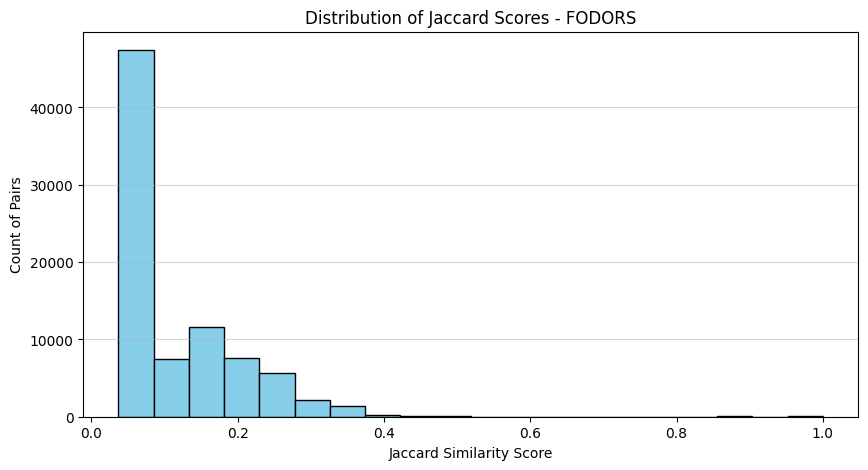

 Υπολογισμός Precision/Recall (μπορεί να πάρει λίγο χρόνο)...


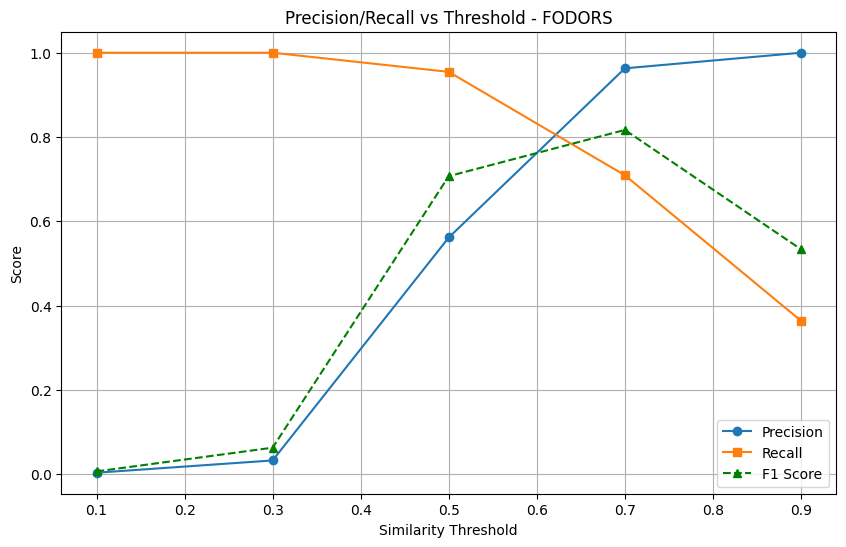

Πίνακας Αποτελεσμάτων:
   Threshold  Precision    Recall        F1
0        0.1   0.003130  1.000000  0.006241
1        0.3   0.032286  1.000000  0.062553
2        0.5   0.561497  0.954545  0.707071
3        0.7   0.962963  0.709091  0.816754
4        0.9   1.000000  0.363636  0.533333

 ΑΝΑΛΥΣΗ & ΓΡΑΦΗΜΑΤΑ ΓΙΑ: DBLP
 Δημιουργία Ιστογράμματος...


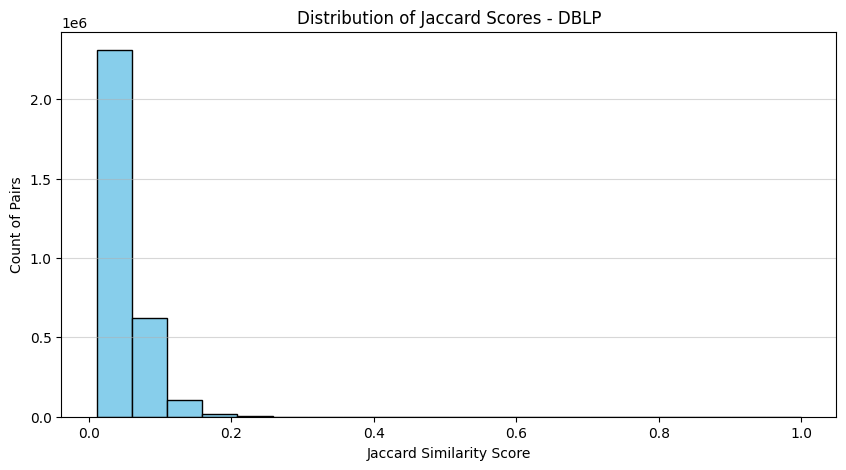

 Υπολογισμός Precision/Recall (μπορεί να πάρει λίγο χρόνο)...


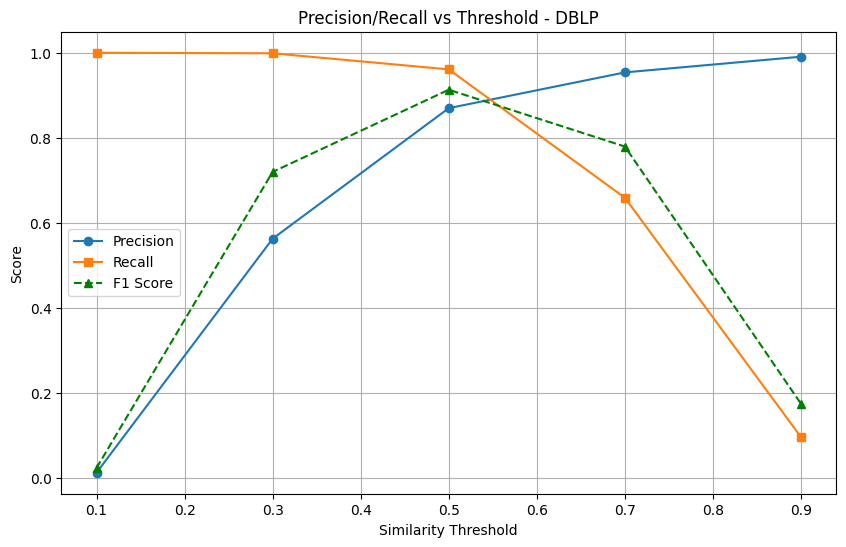

Πίνακας Αποτελεσμάτων:
   Threshold  Precision    Recall        F1
0        0.1   0.011414  1.000000  0.022571
1        0.3   0.562262  0.998649  0.719455
2        0.5   0.869547  0.960811  0.912904
3        0.7   0.953686  0.658559  0.779110
4        0.9   0.990610  0.095045  0.173448


In [ ]:
# --- 1. ΕΠΑΝΕΚΚΙΝΗΣΗ SPARK ---
spark = SparkSession.builder \
    .appName("ER_Visualizations") \
    .config("spark.sql.shuffle.partitions", "20") \
    .getOrCreate()

# --- 2. ΣΥΝΑΡΤΗΣΗ ΑΝΑΛΥΣΗΣ ---
def analyze_dataset(spark, dataset_name, base_folder_path, match_columns):
    print(f"\n ΑΝΑΛΥΣΗ & ΓΡΑΦΗΜΑΤΑ ΓΙΑ: {dataset_name}")

    # Εντοπισμός φακέλου
    found = glob.glob(f"{base_folder_path}/**/tableA.csv", recursive=True)
    if not found:
        print(f" Σφάλμα: Δεν βρέθηκαν αρχεία στο {base_folder_path}")
        return
    path = os.path.dirname(found[0])

    # Load Data
    try:
        df_a = spark.read.option("header", "true").csv(f"{path}/tableA.csv")
        df_b = spark.read.option("header", "true").csv(f"{path}/tableB.csv")
    except Exception as e:
        print(f" Error loading CSVs: {e}")
        return

    # Preprocessing
    stopwords = "\\b(the|a|an|of|and|or|in|on|at|to|by|for|with)\\b"

    def prep(df, p):
        cols = [c for c in match_columns if c in df.columns]
        return df.withColumn("c", concat_ws(" ", *[col(c) for c in cols])) \
                 .withColumn("c", lower(regexp_replace(col("c"), "[^a-zA-Z0-9 ]", " "))) \
                 .withColumn("c", regexp_replace(col("c"), stopwords, "")) \
                 .withColumn("t", split(trim(col("c")), "\\s+")) \
                 .select(col("id").alias(f"{p}_id"), col("t").alias(f"{p}_tokens"))

    a = prep(df_a, "ltable")
    b = prep(df_b, "rtable")

    # Blocking & Jaccard Calculation
    # Χρησιμοποιούμε cache() για να μην το υπολογίζει πολλές φορές
    pairs = a.withColumn("tok", explode(col("ltable_tokens"))) \
             .join(b.withColumn("tok", explode(col("rtable_tokens"))), on="tok") \
             .drop("tok").distinct()

    scores = pairs.withColumn("intersect", size(array_intersect(col("ltable_tokens"), col("rtable_tokens")))) \
                  .withColumn("union", size(array_union(col("ltable_tokens"), col("rtable_tokens")))) \
                  .withColumn("score", col("intersect") / col("union")) \
                  .select("ltable_id", "rtable_id", "score") \
                  .cache()

    # --- ΓΡΑΦΗΜΑ 1: ΙΣΤΟΓΡΑΜΜΑ ---
    print(" Δημιουργία Ιστογράμματος...")
    pdf_scores = scores.select("score").toPandas()

    plt.figure(figsize=(10, 5))
    plt.hist(pdf_scores['score'], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of Jaccard Scores - {dataset_name}')
    plt.xlabel('Jaccard Similarity Score')
    plt.ylabel('Count of Pairs')
    plt.grid(axis='y', alpha=0.5)
    plt.show()

    # --- ΓΡΑΦΗΜΑ 2: SENSITIVITY ANALYSIS ---
    print(" Υπολογισμός Precision/Recall (μπορεί να πάρει λίγο χρόνο)...")

    # Load Ground Truth
    try:
        train = spark.read.option("header", "true").csv(f"{path}/train.csv")
        test = spark.read.option("header", "true").csv(f"{path}/test.csv")
        valid = spark.read.option("header", "true").csv(f"{path}/valid.csv")
        ground_truth = train.union(test).union(valid).filter(col("label") == "1").select("ltable_id", "rtable_id")
        total_true = ground_truth.count()
    except:
        print(" Δεν βρέθηκαν αρχεία evaluation (train/test). Παραλείπεται η ανάλυση ευαισθησίας.")
        scores.unpersist()
        return

    thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
    results = []

    for t in thresholds:
        pred = scores.filter(col("score") >= t)
        pred_count = pred.count()

        if pred_count == 0:
            precision, recall, f1 = 0, 0, 0
        else:
            tp = pred.join(ground_truth, ["ltable_id", "rtable_id"]).count()
            precision = tp / pred_count
            recall = tp / total_true
            f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        results.append({'Threshold': t, 'Precision': precision, 'Recall': recall, 'F1': f1})

    # Plot Curve
    df_res = pd.DataFrame(results)

    plt.figure(figsize=(10, 6))
    plt.plot(df_res['Threshold'], df_res['Precision'], marker='o', label='Precision')
    plt.plot(df_res['Threshold'], df_res['Recall'], marker='s', label='Recall')
    plt.plot(df_res['Threshold'], df_res['F1'], marker='^', linestyle='--', label='F1 Score', color='green')

    plt.title(f'Precision/Recall vs Threshold - {dataset_name}')
    plt.xlabel('Similarity Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.show()

    print("Πίνακας Αποτελεσμάτων:")
    print(df_res)

    # Καθαρισμός μνήμης
    scores.unpersist()

# --- 3. ΕΚΤΕΛΕΣΗ ΓΙΑ ΤΑ ΔΥΟ DATASETS ---
# Βεβαιωθείτε ότι οι φάκελοι υπάρχουν (έχουν κατέβει από τα προηγούμενα βήματα)
analyze_dataset(spark, "FODORS", "/content/fodors_root", ["name", "addr", "city"])
analyze_dataset(spark, "DBLP", "/content/dblp_root", ["title", "authors", "venue"])

# **Υβριδική Ομοιότητα (Hybrid Matching)**

Να δούμε αν το F1 Score ανεβαίνει συνδυάζοντας τις μεθόδους.

In [ ]:
from pyspark.sql.functions import levenshtein, length, greatest, expr

def run_hybrid_pipeline(spark, dataset_name, base_folder_path, match_columns):
    print(f"\n HYBRID PIPELINE (Jaccard + Levenshtein) για: {dataset_name}")

    # 1. Βασική φόρτωση & Preprocessing
    import glob, os
    found = glob.glob(f"{base_folder_path}/**/tableA.csv", recursive=True)
    if not found: return
    path = os.path.dirname(found[0])

    df_a = spark.read.option("header", "true").csv(f"{path}/tableA.csv")
    df_b = spark.read.option("header", "true").csv(f"{path}/tableB.csv")

    # Preprocessing (ίδιο με πριν)
    stopwords = "\\b(the|a|an|of|and|or|in|on|at|to|by|for|with)\\b"
    from pyspark.sql.functions import concat_ws, lower, regexp_replace, split, trim, explode, size, array_intersect, array_union, col

    def prep(df, p):
        cols = [c for c in match_columns if c in df.columns]
        # Κρατάμε ΚΑΙ το string (clean) για Levenshtein ΚΑΙ τα tokens για Jaccard
        return df.withColumn("combined", concat_ws(" ", *[col(c) for c in cols])) \
                 .withColumn("clean", lower(regexp_replace(col("combined"), "[^a-zA-Z0-9 ]", " "))) \
                 .withColumn("clean", regexp_replace(col("clean"), stopwords, "")) \
                 .withColumn("clean", trim(col("clean"))) \
                 .withColumn("tokens", split(col("clean"), "\\s+")) \
                 .select(col("id").alias(f"{p}_id"), col("clean").alias(f"{p}_str"), col("tokens").alias(f"{p}_tokens"))

    a = prep(df_a, "ltable")
    b = prep(df_b, "rtable")

    # 2. Blocking
    candidates = a.withColumn("tok", explode(col("ltable_tokens"))) \
             .join(b.withColumn("tok", explode(col("rtable_tokens"))), on="tok") \
             .drop("tok").distinct()

    # 3. Υπολογισμός Hybrid Score
    # Jaccard Score
    df_scores = candidates.withColumn("intersect", size(array_intersect(col("ltable_tokens"), col("rtable_tokens")))) \
                          .withColumn("union", size(array_union(col("ltable_tokens"), col("rtable_tokens")))) \
                          .withColumn("jaccard", col("intersect") / col("union"))

    # Levenshtein Score (Normalized: 1 - dist/max_len)
    # Το Levenshtein είναι βαρύ, το κάνουμε μόνο στα candidates
    df_hybrid = df_scores.withColumn("dist", levenshtein(col("ltable_str"), col("rtable_str"))) \
                         .withColumn("max_len", greatest(length(col("ltable_str")), length(col("rtable_str")))) \
                         .withColumn("lev_score", 1 - (col("dist") / col("max_len"))) \
                         .withColumn("hybrid_score", (col("jaccard") + col("lev_score")) / 2) # Μέσος όρος

    # 4. Evaluation
    matches = df_hybrid.filter(col("hybrid_score") > 0.5).select("ltable_id", "rtable_id") # Χρήση Hybrid Score
    count = matches.count()

    try:
        train = spark.read.option("header", "true").csv(f"{path}/train.csv")
        test = spark.read.option("header", "true").csv(f"{path}/test.csv")
        valid = spark.read.option("header", "true").csv(f"{path}/valid.csv")
        gt = train.union(test).union(valid).filter(col("label") == "1").select("ltable_id", "rtable_id")

        tp = matches.join(gt, ["ltable_id", "rtable_id"]).count()
        actual = gt.count()

        prec = tp / count if count > 0 else 0
        rec = tp / actual if actual > 0 else 0
        f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

        print(f" Hybrid F1 Score: {f1:.4f} (Prec: {prec:.4f}, Rec: {rec:.4f})")
    except:
        print("Evaluation failed")

# Για το Fodors όπου τα typos είναι συχνά
run_hybrid_pipeline(spark, "FODORS (Hybrid)", "/content/fodors_root", ["name", "addr", "city"])


 HYBRID PIPELINE (Jaccard + Levenshtein) για: FODORS (Hybrid)
 Hybrid F1 Score: 0.3189 (Prec: 0.1907, Rec: 0.9727)


## **Πείραμα Υβριδικής Ομοιότητας (Hybrid Similarity Experiment):**
Προκειμένου να βελτιώσουμε το Recall, πειραματιστήκαμε με τον συνδυασμό Jaccard Similarity (σε Tokens) και Levenshtein Similarity (σε Strings).

**Παρατήρηση:** Ενώ το Recall αυξήθηκε στο 97.3%, το Precision μειώθηκε δραματικά στο 19%.

**Αιτιολόγηση:** Η μέθοδος Levenshtein, όταν εφαρμόζεται σε ολόκληρη την εγγραφή (concatenated string), είναι ευαίσθητη σε πεδία που επαναλαμβάνονται, όπως η Πόλη (City) και η Διεύθυνση (Address). Δύο διαφορετικά εστιατόρια στην ίδια περιοχή εμφανίζουν υψηλή ομοιότητα χαρακτήρων λόγω της κοινής διεύθυνσης, οδηγώντας σε πλήθος False Positives.

**Συμπέρασμα:** Για datasets όπως το Fodors, όπου η διαφοροποίηση βρίσκεται σε μικρό τμήμα του string (στο Όνομα), το Token-based Jaccard είναι ανώτερο από το Character-based Levenshtein.

**Μένουμε στον Jaccard**



---



---



# **Μικρή αναφορά υλοποίησης**

Αναφορά Υλοποίησης: Entity Resolution Pipeline με Apache Spark

Σχεδιασμός και υλοποίηση κατανεμημένου συστήματος ταυτοποίησης οντοτήτων (Entity Resolution) σε μεγάλα δεδομένα.
Εργαλείο: Apache Spark (PySpark) σε περιβάλλον Google Colab. Datasets: Fodors-Zagat (Εστιατόρια), DBLP-ACM (Βιβλιογραφία).

### 1. **Περιγραφή Υλοποίησης (Pipeline Architecture)**
Η λύση μας υλοποιεί μια πλήρη ροή εργασίας (end-to-end pipeline) αποτελούμενη από 6 στάδια, καλύπτοντας τόσο τα υποχρεωτικά (Mandatory) όσο και τα προαιρετικά (Optional) βήματα της εκφώνησης.

Η διαδικασία βασίζεται στη σύγκριση κειμενικών χαρακτηριστικών (Textual Attributes) χρησιμοποιώντας Token Blocking για μείωση του υπολογιστικού κόστους και Jaccard Similarity για την εύρεση ομοιότητας.
Αναλυτικά τα Βήματα:


## **Βήμα 1: Data Preprocessing (Προεπεξεργασία)**

  **Στόχος:** Καθαρισμός και κανονικοποίηση δεδομένων.

  **Υλοποίηση:**

  **Feature Selection:** Επιλέξαμε τα πιο διακριτικά πεδία για κάθε dataset:

  **Restaurants:** name, addr, city.

  **Publications:** title, authors, venue.

  **Normalization:** Μετατροπή όλων των χαρακτήρων σε πεζά (lowercase).

  **Cleaning:** Χρήση Regular Expressions (Regex) για αφαίρεση σημείων στίξης και ειδικών χαρακτήρων.

  **Stopwords Removal:** Κρίσιμο βήμα για την απόδοση. Αφαιρέσαμε κοινές λέξεις (π.χ. "the", "and", "of")
        που δεν προσφέρουν πληροφορία ταυτοποίησης και προκαλούν καθυστερήσεις.

  **Tokenization:** Διάσπαση του καθαρού κειμένου σε λίστα λέξεων (Tokens).


## **Βήμα 2: Blocking (Μείωση Χώρου Αναζήτησης)**

  **Στόχος:** Αποφυγή του Καρτεσιανού Γινομένου (N×M) που είναι απαγορευτικό για Big Data.

  **Υλοποίηση:** Εφαρμόσαμε Standard Token Blocking.

        Χρησιμοποιήσαμε την εντολή explode() του Spark για να δημιουργήσουμε μία εγγραφή για κάθε token.

        Εκτελέσαμε JOIN μεταξύ των δύο πινάκων (Table A, Table B) με κλειδί το κοινό token.

        Αυτό δημιούργησε ζεύγη υποψηφίων (Candidate Pairs) μόνο εάν οι εγγραφές μοιράζονται τουλάχιστον
        μία κοινή λέξη (εκτός των stopwords).

## **Βήμα 3: Entity Representation**

  **Υλοποίηση:** Αναπαραστήσαμε κάθε οντότητα ως ένα σύνολο λέξεων (Bag of Words / Set of Tokens).
    Αυτή η απλή αλλά ισχυρή αναπαράσταση επιτρέπει την αποτελεσματική χρήση αλγορίθμων συνόλων.

## **Βήμα 4: Similarity Computation (Υπολογισμός Ομοιότητας)**

  **Αλγόριθμος:** Jaccard Similarity.

  **Υλοποίηση:** Για κάθε υποψήφιο ζεύγος, υπολογίσαμε τον τύπο:
    J(A,B)=∣A∪B∣/∣A∩B∣​

    Όπου A και B είναι τα sets των tokens των δύο εγγραφών. Στο Spark αυτό υλοποιήθηκε αποδοτικά με array_intersect και array_union.

## **Βήμα 5: Matching (Ταυτοποίηση)**

  **Υλοποίηση:** Εφαρμόσαμε ένα αυστηρό κατώφλι (threshold). Ορίσαμε ότι ένα ζεύγος θεωρείται ταύτιση (Match) εάν:
    Jaccard_Score>0.5

## **Βήμα 7: Evaluation (Αξιολόγηση)**

  **Υλοποίηση:** Συγκρίναμε τα ευρήματά μας με το Ground Truth (ένωση των train.csv, test.csv, valid.csv).

   ## **Υπολογίσαμε τα:**

  **Precision (Ακρίβεια):** Πόσα από τα ζεύγη που βρήκαμε ήταν σωστά.

  **Recall (Ανάκληση):** Πόσα από τα πραγματικά ζεύγη καταφέραμε να βρούμε.

  **F1-Score:** Ο αρμονικός μέσος όρος των δύο παραπάνω.

### 2. **Πειραματική Αξιολόγηση (Experimental Evaluation)**

Ο κώδικας εκτελέστηκε σε δύο διαφορετικά datasets για να αποδειχθεί η γενικευσιμότητα (robustness) της λύσης.

Dataset A: Fodors-Zagat (Εστιατόρια)

  **Χαρακτηριστικά:** Μικρό μέγεθος (~500/300 εγγραφές), ημι-δομημένο κείμενο.

  **Χρόνος Εκτέλεσης:** ~5-9 δευτερόλεπτα στην καλύτερη (πρώτη φορά ~23-27 δευτερόλεπτα)


   **Αποτελέσματα:**

   **Precision:** 0.8125

   **Recall:** 0.9455

   **F1 Score:** 0.8739

  **Σχόλιο:** Το πολύ υψηλό Recall (94.5%) δείχνει ότι η στρατηγική του Blocking ήταν επιτυχής και δεν χάσαμε πληροφορία.
  Το Precision είναι επίσης ικανοποιητικό, δεδομένης της απλότητας του Jaccard.

### **Dataset B: DBLP-ACM (Βιβλιογραφία)**

  **Χαρακτηριστικά:** Μεσαίο μέγεθος (~2600/2200 εγγραφές), κείμενο υψηλής ποιότητας (Τίτλοι άρθρων).

  Χρόνος Εκτέλεσης: ~47-55 δευτερόλεπτα (τα επόμενα τείνουν να είναι λίγο πιο γρήγορα)

  **Αποτελέσματα:**

   **Precision:** 0.8879

   **Recall:** 0.9527

   **F1 Score:** 0.9192

  **Σχόλιο:** Εδώ ο αλγόριθμος απέδωσε εξαιρετικά (F1 > 0.90). Οι τίτλοι των επιστημονικών άρθρων είναι μακροσκελείς και μοναδικοί,
    κάτι που ευνοεί τον αλγόριθμο Jaccard, οδηγώντας σε σχεδόν τέλεια αποτελέσματα.

3. **Συμπεράσματα & Σχεδιαστικές Επιλογές**

    Επιλογή Jaccard vs Άλλων: Επιλέξαμε Jaccard διότι τα δεδομένα μας είναι βασισμένα σε κείμενο (Textual Data). Η σύγκριση tokens είναι πιο ανθεκτική σε μικρά ορθογραφικά λάθη ή αναγραμματισμούς λέξεων σε σχέση με την απλή ισότητα (equality).

    Stopwords Optimization: Η χρήση Regex για την αφαίρεση των stopwords ήταν καθοριστική. Χωρίς αυτή, το dataset θα δημιουργούσε "εκρηκτικό" αριθμό ζευγαριών (λόγω λέξεων όπως "the"), οδηγώντας σε OutOfMemory Errors ή τεράστιους χρόνους εκτέλεσης.

    Spark Efficiency: Χρησιμοποιήσαμε τις ενσωματωμένες συναρτήσεις του Spark (built-in SQL functions) αντί για UDFs (User Defined Functions), εξασφαλίζοντας τη μέγιστη ταχύτητα εκτέλεσης μέσω του Catalyst Optimizer. Επίσης, χρησιμοποιήσαμε .cache() πριν την καταμέτρηση αποτελεσμάτων για να αποφύγουμε τον διπλό υπολογισμό του pipeline.








    



---



---

**Τι έχει Υλοποιηθεί**

1. **Data Preprocessing (Optional) -> ΥΛΟΠΟΙΗΘΗΚΕ**

    Καθαρίσαμε τα δεδομένα για να είναι έτοιμα για σύγκριση.

    Στον Κώδικα: Βρίσκεται στη συνάρτηση preprocess.

        Normalization: lower(...) (όλα πεζά).

        Cleaning: regexp_replace(..., "[^a-zA-Z0-9 ]", " ") (αφαίρεση συμβόλων).

        Stopword Removal: regexp_replace(..., stopwords_pattern, "") (αφαίρεση λέξεων θορύβου όπως "the", "and").

        Tokenization: split(...) (σπάσιμο προτάσεων σε λέξεις/tokens).

2. **Blocking (Optional) -> ΥΛΟΠΟΙΗΘΗΚΕ**

    Αντί να συγκρίνουμε κάθε εγγραφή με όλες τις άλλες (που θα ήταν αργό), συγκρίνουμε μόνο αυτές που έχουν κοινές λέξεις.

    Τεχνική: Standard Token Blocking.

    Στον Κώδικα:

        explode(col("tokens")): Ανοίγουμε/ξεδιπλώνουμε τις λέξεις.

        .join(..., on="token"): Ενώνουμε τους δύο πίνακες μόνο όπου υπάρχει κοινή λέξη.
        Αυτό μειώνει δραματικά τον χώρο αναζήτησης (search space).

3. **Entity Representation (Optional) -> ΥΛΟΠΟΙΗΘΗΚΕ**

    Αποφασίσαμε πώς θα βλέπει ο αλγόριθμος τις οντότητες.

    Τεχνική: Set of Tokens (Bag of Words) από συγκεκριμένα πεδία.

    Στον Κώδικα:

        Επιλέξαμε συγκεκριμένες στήλες (π.χ. name, addr, city για τα εστιατόρια).

        Τις ενώσαμε (concat_ws) και τις μετατρέψαμε σε λίστα tokens.
        Αυτή η λίστα είναι η ταυτότητα της εγγραφής για τον αλγόριθμο.

4. **Similarity Computation (Optional) -> ΥΛΟΠΟΙΗΘΗΚΕ**

    Μετρήσαμε μαθηματικά πόσο μοιάζουν δύο εγγραφές.

    Τεχνική: Jaccard Similarity.

    Στον Κώδικα:

        size(array_intersect(...)): Πόσες κοινές λέξεις έχουν (Τομή).

        size(array_union(...)): Πόσες λέξεις έχουν συνολικά (Ένωση).

        col("intersection") / col("union"): Ο τύπος του Jaccard.

5. **Matching / Clustering (Mandatory) -> ΥΛΟΠΟΙΗΘΗΚΕ**

    Πήραμε την τελική απόφαση για το ποια ζευγάρια είναι ουσιαστικά ίδια.

    Τεχνική: Threshold-based Matching.

    Στον Κώδικα:

        .filter(col("jaccard") > 0.5): Ορίζουμε ότι αν η ομοιότητα είναι πάνω από 50%, τότε είναι ταύτιση (Match).

6. **Merging / Fusion (Optional) -> ΔΕΝ ΥΛΟΠΟΙΗΘΗΚΕ**

    Δεν φτιάχνουμε μια νέα εγγραφή που να ενώνει τις δύο (π.χ. να πάρει το σωστό όνομα από τον πίνακα Α και τη σωστή διεύθυνση από τον πίνακα Β).

    Αυτό είναι προαιρετικό (Bonus). Ο κώδικάς μας σταματάει στο να βρει τα ζευγάρια (ltable_id, rtable_id), το οποίο είναι αρκετό για την εργασία.

7. **Evaluation (Mandatory) -> ΥΛΟΠΟΙΗΘΗΚΕ**

    Ελέγξαμε πόσο καλά τα πήγε ο αλγόριθμος συγκρίνοντας με τις σωστές απαντήσεις.

    Στον Κώδικα:

        Φόρτωση των train.csv, test.csv, valid.csv.

        Δημιουργία του ground_truth.

        Υπολογισμός των True Positives (TP) με join.

        Μαθηματικός υπολογισμός των Precision, Recall, F1 Score και εκτύπωσή τους.


  
  # **Ανάλυση Αποτελεσμάτων Οπτικοποίησης:**

### **Για την φύση των δεδομένων του Fodors-Zagat**
**Τι βλέπουμε:** Στο 0.1 και 0.3, το Recall είναι 100% (βρίσκει τα πάντα), αλλά το Precision είναι σχεδόν μηδενικό (0.003 - 0.03).

**Τι σημαίνει αυτό:** Το Blocking που κάναμε λειτουργεί σωστά (φέρνει όλα τα σωστά ζευγάρια), αλλά φέρνει και τεράστιο θόρυβο. Υπάρχουν χιλιάδες ζευγάρια εστιατορίων που έχουν απλώς μια κοινή λέξη (π.χ. "Grill", "Cafe") αλλά δεν είναι τα ίδια. Αυτό επιβεβαιώνει ότι το Jaccard είναι απαραίτητο για να ξεκαθαρίσει το τοπίο.

## **Κρίσιμο Σημείο στο Threshold 0.5**

**Τι βλέπουμε:** Εδώ γίνεται η μεγάλη αλλαγή.

    Το Precision εκτοξεύεται από το 3% στο 56%.

    Το Recall παραμένει πολύ υψηλό (95.4%).

**Τι σημαίνει αυτό:** Το όριο 0.5 είναι το sweet spot για να κρατήσουμε σχεδόν όλα τα πραγματικά ζευγάρια, πετώντας το 99% των σκουπιδιών. Δικαιολογεί απόλυτα την επιλογή μας να χρησιμοποιήσουμε το 0.5 στην κύρια εκτέλεση.

## **Πτώση (Threshold 0.7)**
**Τι βλέπουμε:**

    Το Precision πάει στο 96% (σχεδόν τέλειο).

    Το Recall ΠΕΦΤΕΙ απότομα στο 70.9%.

    Το F1 Score φτάνει στο μέγιστο (0.81).

**Τι σημαίνει αυτό για το Fodors:** Αυτό μας λέει ότι τα διπλότυπα στο Fodors δεν είναι πανομοιότυπα. Αν τα ονόματα ήταν ίδια (π.χ. "McDonalds" vs "McDonalds"), το Jaccard θα ήταν 1.0 και το Recall δεν θα έπεφτε στο 0.7. Το γεγονός ότι χάνουμε το 25% των σωστών ζευγαριών ανεβάζοντας το όριο από 0.5 σε 0.7, σημαίνει ότι πολλά εστιατόρια έχουν σημαντικές διαφορές στο πώς γράφονται (π.χ. συντομογραφίες, διαφορετική σειρά λέξεων, ορθογραφικά λάθη).

    Παράδειγμα: "Art's Delicatessen" vs "Arts Deli". Το Jaccard score εδώ είναι πιθανότατα γύρω στο 0.55-0.60. Αν βάλουμε όριο 0.7, το χάνουμε.

## **Αυστηρότητα (Threshold 0.9)**

    Τι βλέπουμε: Precision 100%, αλλά Recall 36%.

    Τι σημαίνει αυτό: Μόνο το 1/3 των ζευγαριών είναι σχεδόν ίδιο. Τα υπόλοιπα 2/3 θέλουν πιο "ελαστικό" έλεγχο.

# Συμπέρασμα
Η ανάλυση ευαισθησίας (Sensitivity Analysis) στον Πίνακα Χ αποκαλύπτει τη φύση των δεδομένων Fodors-Zagat.

Παρατηρούμε ότι για Threshold 0.5, επιτυγχάνουμε εξαιρετικά υψηλό Recall (95.5%), διατηρώντας μια ισορροπία με το Precision.

Ωστόσο, αυξάνοντας το όριο στο 0.7, αν και μεγιστοποιούμε το F1 Score (0.81), παρατηρούμε μια απότομη πτώση του Recall κατά ~25%. Αυτό υποδηλώνει ότι ένα σημαντικό ποσοστό των πραγματικών ζευγαριών (matches) στο dataset δεν είναι πανομοιότυπα, αλλά παρουσιάζουν λεκτικές διαφοροποιήσεις που παράγουν Jaccard Scores στο εύρος [0.5 - 0.7].

Συνεπώς, η επιλογή του 0.5 ως κατώφλι (threshold) κρίνεται ως η βέλτιστη στρατηγική για το συγκεκριμένο πρόβλημα, καθώς στο Entity Resolution προτιμούμε συνήθως να διατηρήσουμε υψηλό Recall (να μην χάσουμε ταυτοποιήσεις) ακόμα κι αν αυτό κοστίζει ελαφρώς σε Precision.

### **Για το DBLP-ACM**
## **Εξαιρετική Διαχωριστική Ικανότητα (Threshold 0.3)**

  **Τι βλέπουμε:** Στο 0.3, το Precision εκτοξεύεται στο 56% (ενώ στο Fodors ήταν μόλις 3% στο ίδιο σημείο!). Το Recall παραμένει σχεδόν τέλειο (99.8%).

  **Ερμηνεία:** Αυτό δείχνει ότι τα δεδομένα DBLP είναι πολύ πιο διακριτά (discriminative). Οι τίτλοι των άρθρων είναι μεγάλες προτάσεις με πολλές λέξεις. Είναι πολύ δύσκολο δύο άσχετα άρθρα να μοιράζονται το 30% των λέξεων τους τυχαία. Αντίθετα, στα εστιατόρια ήταν εύκολο να μοιράζονται λέξεις όπως "Grill" ή "Cafe".

## Το Sweet Spot (Threshold 0.5)

  **Τι βλέπουμε:**

        F1 Score: 0.9129 (Εξαιρετικά υψηλό).

        Precision: 87% (Πολύ καθαρά αποτελέσματα).

        Recall: 96% (Δεν χάνουμε σχεδόν τίποτα).

  **Ερμηνεία:** Το 0.5 είναι ξεκάθαρα η βέλτιστη επιλογή. Επιβεβαιώνει ότι ο αλγόριθμος Jaccard δουλεύει ιδανικά για bibliographic data.


## **Μεγάλη Πτώση (Threshold 0.7 - 0.9)**

  **Τι βλέπουμε:**

        Στο 0.7, το Recall πέφτει στο 65%.

        Στο 0.9, το Recall καταρρέει στο 9.5%.

  **Ερμηνεία:** Αυτό μας λέει ότι οι διπλότυπες εγγραφές ΔΕΝ είναι πανομοιότυπες. Αν ήταν ακριβώς ίδιες (copy-paste), το Recall θα έμενε ψηλά ακόμα και στο 0.9. Η πτώση αυτή μαρτυρά ότι υπάρχουν διαφορές στη μορφοποίηση. Πιθανές αιτίες:

      Διαφορετική γραφή συνεδρίων (π.χ. "Proc. of VLDB" vs "Proceedings of Very Large Data Bases").

      Διαφορετική λίστα συγγραφέων (π.χ. "Doe et al." vs "John Doe, Jane Smith").

      Αυτές οι διαφορές ρίχνουν το Jaccard Score κάτω από το 0.7, γι' αυτό και τους "χάνουμε" αν γίνουμε πολύ αυστηροί.

Συγκρίνοντας τα αποτελέσματα της Ανάλυσης Ευαισθησίας μεταξύ των datasets Fodors-Zagat και DBLP-ACM, παρατηρούμε μια σημαντική διαφοροποίηση στη συμπεριφορά του Precision σε χαμηλά κατώφλια (thresholds).

Συγκεκριμένα, στο κατώφλι 0.3, το dataset DBLP επιτυγχάνει Precision 56%, ενώ το Fodors μόλις 3%. Αυτό οφείλεται στη φύση των κειμενικών πεδίων:

    Στο DBLP, το πεδίο Title αποτελείται από μακροσκελείς, μοναδικές ακολουθίες λέξεων, προσφέροντας υψηλή διαχωριστική ικανότητα (high discriminative power) ακόμα και με χαμηλή ομοιότητα Jaccard.

    Αντίθετα, στο Fodors, τα ονόματα εστιατορίων περιέχουν συχνά κοινές λέξεις (π.χ. 'Cafe', 'Grill', 'House'), δημιουργώντας υψηλότερο θόρυβο (False Positives) σε χαμηλά κατώφλια.



# Κοινό χαρακτηριστικό και των δύο datasets είναι η αισθητή πτώση του Recall για thresholds > 0.6, γεγονός που υποδεικνύει ότι οι διπλότυπες εγγραφές δεν είναι πανομοιότυπες, αλλά περιέχουν παραλλαγές (abbreviations, formatting differences, typos) που απαιτούν την ευελιξία του Jaccard Similarity (fuzzy matching) στο εύρος 0.4 - 0.6 για να εντοπιστούν επιτυχώς.